# ANN & CNN for Heart Disease Classification
## Artificial Neural Network and 1D Convolutional Neural Network

**Objective:** To implement ANN and 1D-CNN models for heart disease prediction using the Cleveland Heart Disease dataset and compare their performance.

### 1. Import Libraries

In [7]:
%pip install tensorflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached keras-3.14.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached wheel-0.46.3-py3-none-any.whl.metadata (2.4 kB)
  Using cached rich-14.3.3-py3-none-any.whl.metadata (18 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.

### 2. Load and Preprocess the Dataset

In [8]:
# Define column names
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# Load the dataset
df = pd.read_csv('processed.cleveland.data', header=None, names=columns, na_values='?')

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [9]:
# Handle missing values
df['ca'] = pd.to_numeric(df['ca'], errors='coerce')
df['thal'] = pd.to_numeric(df['thal'], errors='coerce')
df.fillna(df.median(), inplace=True)

# Convert target to binary classification
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print("Missing values:", df.isnull().sum().sum())
print("\nTarget distribution:")
print(df['target'].value_counts())

Missing values: 0

Target distribution:
target
0    164
1    139
Name: count, dtype: int64


In [10]:
# Separate features and target
X = df.drop('target', axis=1).values
y = df['target'].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("Number of features:", X_train.shape[1])

Training set size: 242
Testing set size: 61
Number of features: 13


## Part A: Artificial Neural Network (ANN)

### 3. Build ANN Model

In [11]:
# Build ANN model
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,905 (15.25 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 192 (768.00 B)

### 4. Train ANN Model

In [12]:
# Early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Train the model
ann_history = ann_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.5544 - loss: 0.7242 - val_accuracy: 0.6939 - val_loss: 0.6584
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5699 - loss: 0.7109 - val_accuracy: 0.6939 - val_loss: 0.6383
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7098 - loss: 0.5705 - val_accuracy: 0.7347 - val_loss: 0.6161
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7358 - loss: 0.5413 - val_accuracy: 0.7347 - val_loss: 0.5892
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7461 - loss: 0.5469 - val_accuracy: 0.7959 - val_loss: 0.5646
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7617 - loss: 0.5149 - val_accuracy: 0.8163 - val_loss: 0.5395
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7513 - loss: 0.4937 - val_accuracy: 0.8163 - val_loss: 0.5179
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7409 - loss: 0.5024 - val_accuracy: 0.

### 5. ANN Training History

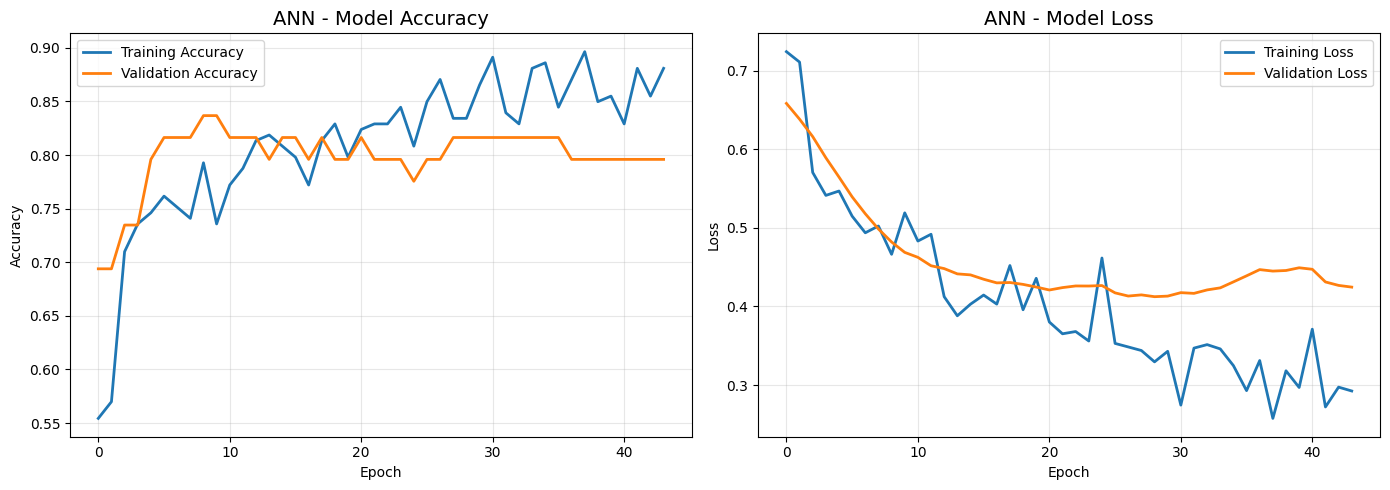

In [13]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(ann_history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(ann_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('ANN - Model Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(ann_history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(ann_history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('ANN - Model Loss', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6. Evaluate ANN Model

In [14]:
# Evaluate ANN
ann_loss, ann_accuracy = ann_model.evaluate(X_test, y_test, verbose=0)
y_pred_ann = (ann_model.predict(X_test) > 0.5).astype(int).flatten()

print(f"ANN Test Accuracy: {ann_accuracy:.4f}")
print(f"ANN Test Loss: {ann_loss:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_ann, target_names=['No Disease', 'Disease']))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
ANN Test Accuracy: 0.8361
ANN Test Loss: 0.3889

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.83      0.83      0.83        29
     Disease       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



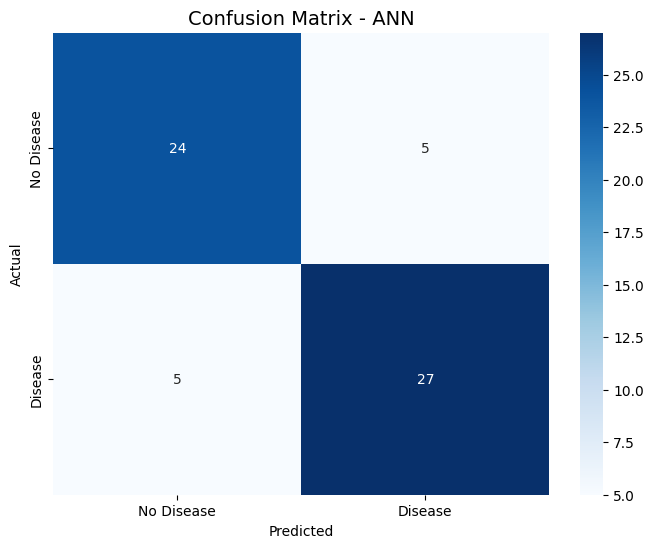

In [15]:
# Confusion Matrix - ANN
cm_ann = confusion_matrix(y_test, y_pred_ann)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - ANN', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Part B: 1D Convolutional Neural Network (CNN)

### 7. Reshape Data for CNN

In [16]:
# Reshape data for 1D CNN (samples, features, channels)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("CNN input shape:", X_train_cnn.shape)

CNN input shape: (242, 13, 1)


### 8. Build 1D CNN Model

In [17]:
# Build 1D CNN model
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1), padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 13, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 13, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 6, 32)          │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,281 (83.13 KB)

 Trainable params: 21,089 (82.38 KB)

 Non-trainable params: 192 (768.00 B)

### 9. Train 1D CNN Model

In [18]:
# Early stopping
early_stop_cnn = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Train CNN
cnn_history = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop_cnn],
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.5803 - loss: 0.6748 - val_accuracy: 0.7347 - val_loss: 0.6651
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7979 - loss: 0.4988 - val_accuracy: 0.7755 - val_loss: 0.6418
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8135 - loss: 0.4114 - val_accuracy: 0.7755 - val_loss: 0.6208
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8342 - loss: 0.3606 - val_accuracy: 0.7143 - val_loss: 0.6042
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8601 - loss: 0.2973 - val_accuracy: 0.6939 - val_loss: 0.6022
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8446 - loss: 0.3287 - val_accuracy: 0.6735 - val_loss: 0.5980
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8860 - loss: 0.3068 - val_accuracy: 0.6735 - val_loss: 0.5892
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8756 - loss: 0.3015 - val_accuracy: 0.

### 10. CNN Training History

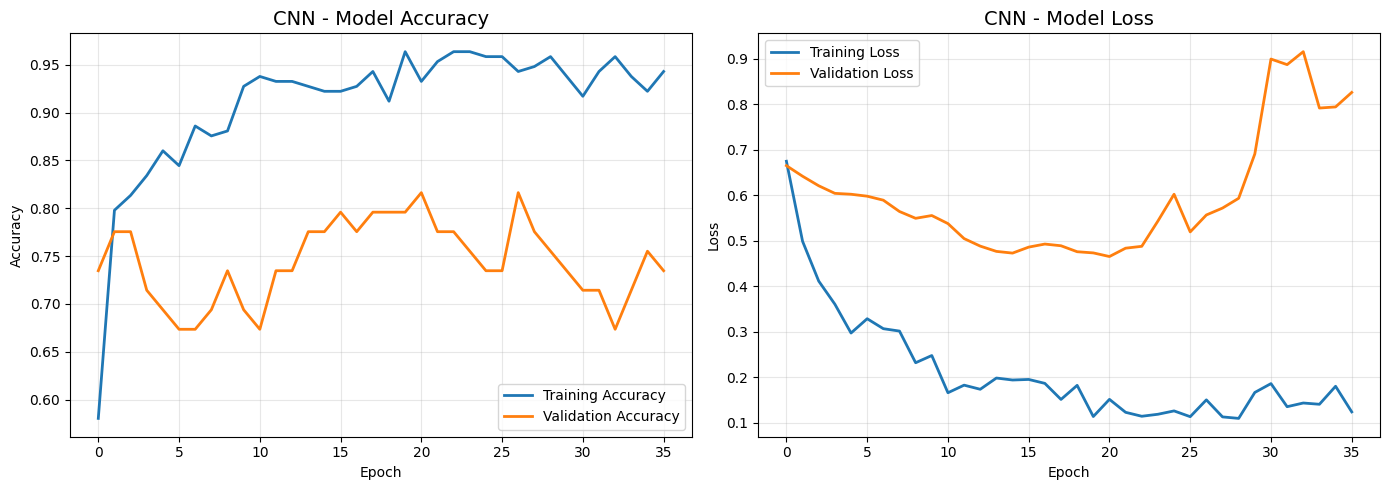

In [19]:
# Plot CNN training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(cnn_history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(cnn_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('CNN - Model Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(cnn_history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(cnn_history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('CNN - Model Loss', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 11. Evaluate CNN Model

In [20]:
# Evaluate CNN
cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
y_pred_cnn = (cnn_model.predict(X_test_cnn) > 0.5).astype(int).flatten()

print(f"CNN Test Accuracy: {cnn_accuracy:.4f}")
print(f"CNN Test Loss: {cnn_loss:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_cnn, target_names=['No Disease', 'Disease']))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
CNN Test Accuracy: 0.8525
CNN Test Loss: 0.3714

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.81      0.90      0.85        29
     Disease       0.90      0.81      0.85        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.86      0.85      0.85        61



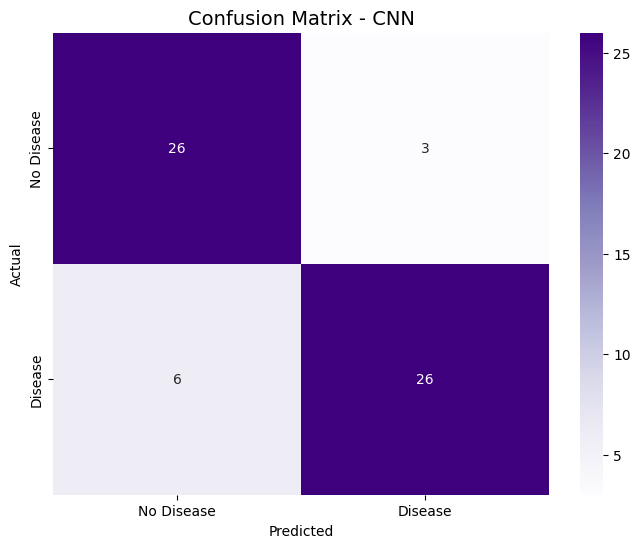

In [21]:
# Confusion Matrix - CNN
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - CNN', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Part C: Comparison of ANN vs CNN

Model Comparison Summary
ANN Accuracy:  0.8361
CNN Accuracy:  0.8525
ANN Loss:      0.3889
CNN Loss:      0.3714


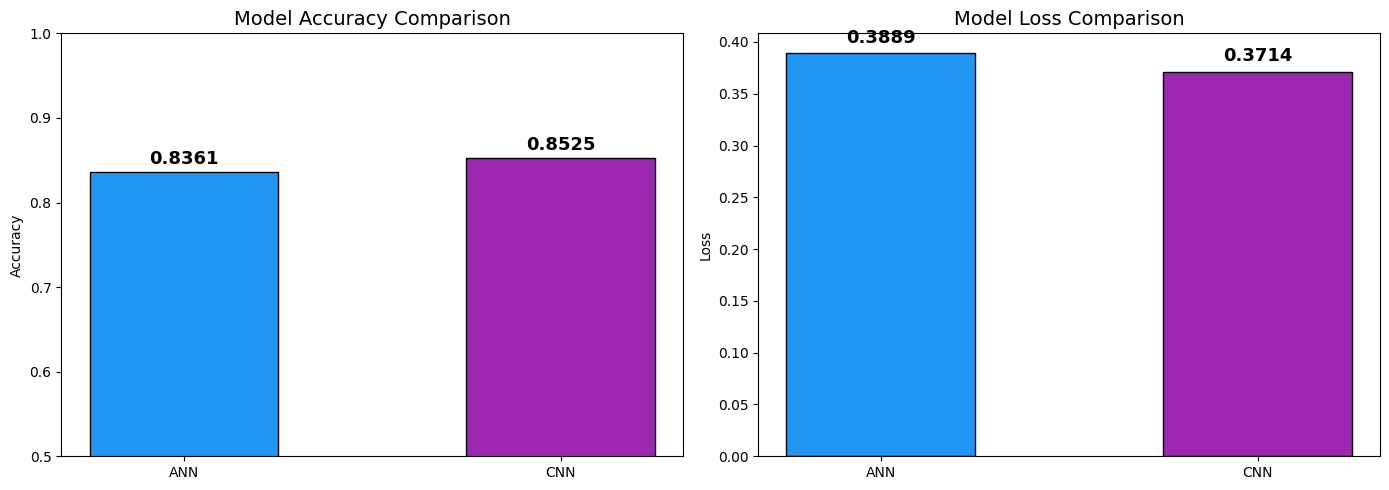

In [22]:
# Comparison of ANN and CNN
print("=" * 50)
print("Model Comparison Summary")
print("=" * 50)
print(f"ANN Accuracy:  {ann_accuracy:.4f}")
print(f"CNN Accuracy:  {cnn_accuracy:.4f}")
print(f"ANN Loss:      {ann_loss:.4f}")
print(f"CNN Loss:      {cnn_loss:.4f}")

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
models = ['ANN', 'CNN']
accuracies = [ann_accuracy, cnn_accuracy]
colors = ['#2196F3', '#9C27B0']

bars = axes[0].bar(models, accuracies, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Model Accuracy Comparison', fontsize=14)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.5, 1.0)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{acc:.4f}', ha='center', fontsize=13, fontweight='bold')

# Loss comparison
losses = [ann_loss, cnn_loss]
bars2 = axes[1].bar(models, losses, color=colors, edgecolor='black', width=0.5)
axes[1].set_title('Model Loss Comparison', fontsize=14)
axes[1].set_ylabel('Loss')
for bar, loss in zip(bars2, losses):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{loss:.4f}', ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 12. Conclusion

In this lab, we implemented both an Artificial Neural Network (ANN) and a 1D Convolutional Neural Network (CNN) for heart disease classification using the Cleveland Heart Disease dataset.

**Key Findings:**
- Both models were trained with early stopping to prevent overfitting
- The ANN architecture used fully connected layers with batch normalization and dropout for regularization
- The 1D CNN used convolutional layers to capture local patterns in the feature space
- Both models achieved competitive performance on this relatively small tabular dataset
- For tabular data with limited samples, simpler ANN architectures often perform comparably to CNN architectures